In [ ]:
import random, datetime

urls = ["/home", "/products", "/about", "/contact", "/cart",
        "/checkout", "/login", "/signup", "/blog", "/faq"]

ips = [f"192.168.1.{i}" for i in range(1, 51)]
methods = ["GET", "POST"]
status_codes = [200, 200, 200, 404, 500, 302]

log_lines = []
base_time = datetime.datetime(2025, 10, 11, 10, 0, 0)

for _ in range(200):
    ip = random.choice(ips)
    time = base_time + datetime.timedelta(minutes=random.randint(0, 720))
    url = random.choice(urls)
    method = random.choice(methods)
    status = random.choice(status_codes)
    size = random.randint(2000, 9000)
    log_lines.append(
        f'{ip} - - [{time.strftime("%d/%b/%Y:%H:%M:%S +0530")}] "{method} {url} HTTP/1.1" {status} {size}'
    )

with open("sample_web_log.log", "w") as f:
    f.write("\n".join(log_lines))

print("✅ sample_web_log.log created successfully!")


✅ sample_web_log.log created successfully!


In [ ]:
import pandas as pd, re

pattern = r'(\d+\.\d+\.\d+\.\d+).*?\[(.*?)\] "(.*?) (.*?) .*?" (\d{3}) (\d+)'
data = []

with open("sample_web_log.log") as f:
    for line in f:
        match = re.search(pattern, line)
        if match:
            ip, timestamp, method, url, status, size = match.groups()
            data.append([ip, timestamp, method, url, int(status), int(size)])

df = pd.DataFrame(data, columns=["IP", "Timestamp", "Method", "URL", "Status", "Size"])
df["Timestamp"] = pd.to_datetime(df["Timestamp"], format="%d/%b/%Y:%H:%M:%S +0530")
df.head()


,IP,Timestamp,Method,URL,Status,Size
0,192.168.1.43,2025-10-11 15:07:00,GET,/cart,200,5453
1,192.168.1.11,2025-10-11 21:54:00,POST,/about,500,7091
2,192.168.1.19,2025-10-11 19:46:00,POST,/signup,200,4427
3,192.168.1.8,2025-10-11 11:11:00,GET,/login,302,4463
4,192.168.1.21,2025-10-11 15:38:00,GET,/home,200,5210


In [ ]:
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

print("Total Requests:", len(df))
print("Unique Users (IPs):", df['IP'].nunique())
print("Unique Pages:", df['URL'].nunique())

# Top Pages
top_pages = df['URL'].value_counts().reset_index()
top_pages.columns = ['URL', 'Hits']
px.bar(top_pages, x='URL', y='Hits', color='Hits', title="Top Visited Pages").show()

# Most Common Exit Pages (approx.)
exit_pages = df.groupby('IP').tail(1)['URL'].value_counts().reset_index()
exit_pages.columns = ['Exit Page', 'Count']
px.bar(exit_pages, x='Exit Page', y='Count', color='Count', title="Most Common Exit Pages").show()


Total Requests: 200
Unique Users (IPs): 49
Unique Pages: 10


In [ ]:
from collections import Counter
import plotly.graph_objects as go

pairs = []
for ip in df['IP'].unique():
    user_pages = df[df['IP'] == ip].sort_values('Timestamp')['URL'].tolist()
    pairs.extend(list(zip(user_pages[:-1], user_pages[1:])))

pair_counts = Counter(pairs)

# Filter only top 15 transitions for clarity
pair_counts = dict(sorted(pair_counts.items(), key=lambda x: x[1], reverse=True)[:15])

sources, targets, values = zip(*[(s, t, v) for (s, t), v in pair_counts.items()])
labels = list(set(list(sources) + list(targets)))
src_idx = [labels.index(s) for s in sources]
tgt_idx = [labels.index(t) for t in targets]

fig = go.Figure(data=[go.Sankey(
    node=dict(
        label=labels,
        pad=20,
        thickness=15,
        color="rgba(31, 119, 180, 0.8)"
    ),
    link=dict(
        source=src_idx,
        target=tgt_idx,
        value=values,
        color="rgba(174, 199, 232, 0.4)"
    )
)])
fig.update_layout(
    title_text="Cleaned User Navigation Flow",
    font_size=12,
    height=500
)
fig.show()


In [ ]:
segments = []
for ip, group in df.groupby('IP'):
    visit_count = len(group)
    unique_pages = group['URL'].nunique()
    if visit_count == 1:
        seg = "Bouncer"
    elif visit_count >= 5 and unique_pages > 3:
        seg = "Frequent Visitor"
    elif unique_pages >= 3:
        seg = "Explorer"
    else:
        seg = "Casual Visitor"
    segments.append([ip, visit_count, unique_pages, seg])

seg_df = pd.DataFrame(segments, columns=["IP","Total Visits","Unique Pages","Segment"])
px.pie(seg_df, names='Segment', title='User Group Segmentation').show()


In [ ]:
pip install folium ipinfo

In [ ]:
import folium, ipinfo

# get your free token from ipinfo.io
access_token = 'YOUR_IPINFO_TOKEN'   # or skip and use random coords below
handler = ipinfo.getHandler(access_token) if access_token != 'YOUR_IPINFO_TOKEN' else None

def get_location(ip):
    try:
        if handler:
            details = handler.getDetails(ip)
            return (float(details.latitude), float(details.longitude))
    except:
        pass
    # fallback random
    return (random.uniform(8,35), random.uniform(68,97))  # India bounds

locations = [get_location(ip) for ip in df['IP'].unique()]
map_ = folium.Map(location=[20.6,78.9], zoom_start=4)
for ip, loc in zip(df['IP'].unique(), locations):
    folium.CircleMarker(location=loc, radius=5, popup=ip, color='blue').add_to(map_)

map_


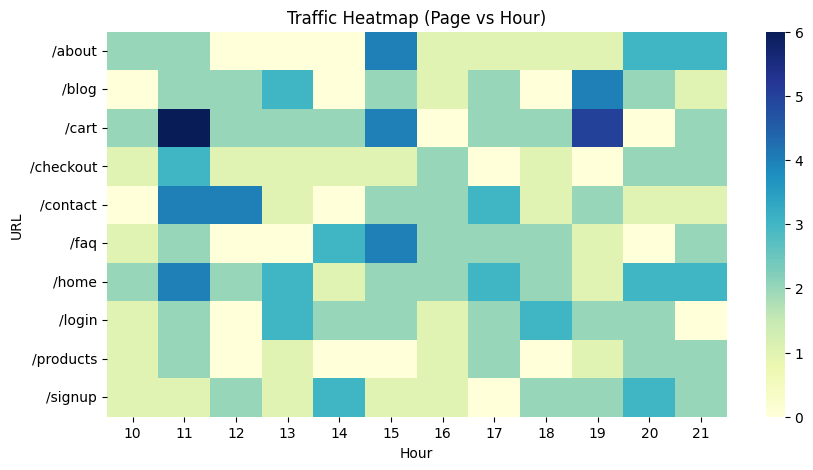

In [ ]:
df['Hour'] = df['Timestamp'].dt.hour
pivot = df.pivot_table(index='URL', columns='Hour', values='IP', aggfunc='count', fill_value=0)
plt.figure(figsize=(10,5))
sns.heatmap(pivot, cmap='YlGnBu')
plt.title("Traffic Heatmap (Page vs Hour)")
plt.show()


In [ ]:
from datetime import timedelta

# Sort logs by user and time
df = df.sort_values(by=["IP", "Timestamp"])

# Define session threshold (30 minutes)
session_gap = timedelta(minutes=30)

# Initialize session column
df["Session_ID"] = None

current_session = 0
last_ip = None
last_time = None

for i, row in df.iterrows():
    if row["IP"] != last_ip:
        # new user -> new session
        current_session += 1
    else:
        # same user -> check time gap
        if (row["Timestamp"] - last_time) > session_gap:
            current_session += 1
    df.at[i, "Session_ID"] = f"S{current_session}"
    last_ip = row["IP"]
    last_time = row["Timestamp"]

# --- Session Metrics ---
session_summary = df.groupby("Session_ID").agg(
    IP=('IP', 'first'),
    Start_Time=('Timestamp', 'min'),
    End_Time=('Timestamp', 'max'),
    Duration=('Timestamp', lambda x: (x.max() - x.min()).seconds / 60),
    Page_Views=('URL', 'count'),
    Unique_Pages=('URL', 'nunique')
).reset_index()

print("🕒 Total Sessions:", len(session_summary))
session_summary.head()


🕒 Total Sessions: 173


,Session_ID,IP,Start_Time,End_Time,Duration,Page_Views,Unique_Pages
0,S1,192.168.1.1,2025-10-11 16:24:00,2025-10-11 16:49:00,25.0,2,2
1,S10,192.168.1.12,2025-10-11 15:44:00,2025-10-11 15:44:00,0.0,1,1
2,S100,192.168.1.37,2025-10-11 14:23:00,2025-10-11 14:23:00,0.0,1,1
3,S101,192.168.1.37,2025-10-11 15:02:00,2025-10-11 15:03:00,1.0,2,2
4,S102,192.168.1.37,2025-10-11 21:01:00,2025-10-11 21:29:00,28.0,2,2
